In [16]:
#AI was used to help generate this code. Code was tested and verified.
#Model used to generate code: qwen-coder:30b

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import matplotlib.cm as cm

# Create visuals inside notebook
%matplotlib inline

# Set Up for Report

## Setting Up Functions to Use Later
- **load_transactions()-**
loads csv file with path name
- **create_mirror_transfers()-**
creates opposite transactions for transfers so both accounts can be updated in calculate_acount_balances()
- **calculate_account_balances()-**
combines the csv file df with the transfers_df created with create_mirror_transfers() to create a complete set of transfers that it calculates account balances for
- **get_category_sums_and_averages-**
Gets total expenses by category and their monthly average. Used to forecast account balance. 
- **display_category_sums_and_averages-**
Show average expenses by month in a table. Used for data verification. Not needed to create report.

In [17]:
def load_transactions(file_path):

    try:
        #Use pandas to read csv file in absolute path. See last block. 
        df = pd.read_csv(file_path)
        
        #Checking all columns are in CSV file
        required_columns = ['Type', 'Account', 'Item', 'Category', 'Amount', 'Date']
        if not all(col in df.columns for col in required_columns):
            raise ValueError(f"CSV must contain columns: {required_columns}")
        
        #Convert Date column to datetime
        df['Date'] = pd.to_datetime(df['Date'])
        
        #Sort by date. Reset index and get rid of old index
        df = df.sort_values('Date').reset_index(drop=True)
        
        return df
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        raise  

In [18]:
def create_mirror_transfers(df):
    #Create mirror transfer transactions by swapping Account and Item field values
    # Filter for transfer transactions
    transfer_df = df[df['Type'] == 'Transfer'].copy()
    
    #Swap the values in Account and Item columns.
    temp = transfer_df['Account'].copy()
    transfer_df['Account'] = transfer_df['Item']
    transfer_df['Item'] = temp
    
    #Make the amounts negative
    transfer_df['Amount'] = -transfer_df['Amount']

    #Reset index
    transfer_df = transfer_df.reset_index(drop=True)
    
    return transfer_df

In [19]:
def calculate_account_balances(df, transfers_df):
    #Calculate running balance for each account
    #Create a copy to avoid modifying original data
    df_copy = df.copy()
    
    # Merge dataframes
    #Combine original transactions with mirror transfers
    df_copy = pd.concat([df_copy, transfers_df], ignore_index=True)
    #Sort by date again after merging
    df_copy = df_copy.sort_values('Date').reset_index(drop=True)
    
    #Create empty dictionary to track balances
    account_balances = {}
    
    #Process each transaction
    for idx, row in df_copy.iterrows():
        transaction_type = row['Type']
        account = row['Account']
        amount = row['Amount']
        
        if account not in account_balances:
            account_balances[account] = 0

        if transaction_type == "Withdrawal":
            account_balances[account] -= amount
        elif transaction_type == "Deposit":
            account_balances[account] += amount
        elif transaction_type == "Credit Payment":
            account_balances['Account 3'] -= amount
            account_balances['Credit Charge'] += amount
        elif transaction_type == "Transfer":
            account_balances[account] -= amount
        df_copy.loc[idx, 'Balance'] = account_balances[account]
    
    return df_copy


In [20]:
def get_category_sums_and_averages(df):
    """Calculate total and average monthly spending by category."""
    
    # Filter transactions
    filtered_df = df[df['Type'] != 'Credit Payment']
    withdrawals = filtered_df[filtered_df['Type'] == 'Withdrawal']
    
    # Filter date range to June 2024 to Present
    start_date = pd.to_datetime('2024-06-01')
    end_date = withdrawals['Date'].max()
    withdrawals = withdrawals[(withdrawals['Date'] >= start_date) & (withdrawals['Date'] <= end_date)]
    
    # Create monthly groups
    withdrawals['Month'] = withdrawals['Date'].dt.to_period('M')
    
    # Get all unique months
    all_months = pd.period_range(start=start_date, end=end_date, freq='M')
    
    # Group by month and category, sum amounts
    monthly_category_sums = withdrawals.groupby(['Month', 'Category'])['Amount'].sum().reset_index()
    
    # Create complete grid of all months and categories
    all_combinations = pd.MultiIndex.from_product([all_months, withdrawals['Category'].unique()], names=['Month', 'Category']).to_frame(index=False)
    
    # Merge and fill missing values
    complete_data = all_combinations.merge(monthly_category_sums, on=['Month', 'Category'], how='left')
    complete_data['Amount'] = complete_data['Amount'].fillna(0)
    
    # Calculate totals and averages
    total_sums = complete_data.groupby('Category')['Amount'].sum() #Isn't used. Just a nice to have. Is used in display_category_sums_and_averages()
    average_sums = complete_data.groupby('Category')['Amount'].mean()
    
    return total_sums, average_sums



In [21]:
def display_category_sums_and_averages(df):
    """Displays the total and average monthly sums for each category in a formatted table. For verification puposes"""
    total_sums, average_sums = get_category_sums_and_averages(df)
    
    # Create a DataFrame for better display
    result_df = pd.DataFrame({
        'Total Amount': total_sums,
        'Average Monthly': average_sums
    })
    
    # Round to 2 decimal places
    result_df = result_df.round(2)
    
    print("Category Spending Summary (June 2024 - Present)")
    print("=" * 50)
    total_spending = total_sums.sum()
    average_monthly_spending = average_sums.sum()
    print(f"Total spending across all categories: ${total_spending:,.2f}")
    print(f"Average monthly spending across all categories: ${average_monthly_spending:,.2f}")
    
    return result_df

# Can't run below until transactions_df_with_future_balances is initialized
#display_category_sums_and_averages(transactions_df_with_future_balances)

## Running Above Functions to Use for Report

In [22]:
transactions_df = load_transactions('./Randomized Transaction Data/transactions_matplotlib_rand.csv')
transfers_transactions_df = create_mirror_transfers(transactions_df)
transactions_df_with_balances = calculate_account_balances(transactions_df, transfers_transactions_df)
transactions_df_with_balances['Date'] = pd.to_datetime(transactions_df_with_balances['Date'])

future_transactions_df = load_transactions('./Randomized Transaction Data/future_transactions_matplotlib_rand.csv')
transactions_df_with_future_balances = calculate_account_balances(transactions_df_with_balances, future_transactions_df)
transactions_df_with_future_balances['Date'] = pd.to_datetime(transactions_df_with_future_balances['Date'])

# Creating Report

## Page 1

### Create Values for Page 1 of Report
Structuring data to use with visuals. Filtering out Credit Payments, grouping transactions by months. Pi chart takes up 2/3rds of this set up.

In [23]:
# Rename df_with_balances for ease of use
df = transactions_df_with_balances

# df_filtered removes Credit Payments and Groups Amounts by Month
df_filtered = df[df['Type'] != 'Credit Payment']
df_filtered['Month'] = df_filtered['Date'].dt.to_period('M')

"""Expenses vs Income"""
# Calculate expenses (sum of Withdrawal amounts) and income (sum of Deposit containing Paycheck)
expenses = df_filtered[df_filtered['Type'] == 'Withdrawal'].groupby('Month')['Amount'].sum()
income = df_filtered[(df_filtered['Type'] == 'Deposit') & (df_filtered['Item'].str.contains('Paycheck', na=False))].groupby('Month')['Amount'].sum()

"""Monthly Account Balances"""
# Create a pivot table for plotting
pivot_df = df_filtered.pivot_table(index='Date', columns='Account', values='Balance', aggfunc='last')
    
# Group by month and get the last balance of each month. Forward fill for months when there are no balance updates
monthly_balances = pivot_df.groupby(pivot_df.index.to_period('M')).last()
monthly_balances=monthly_balances.replace(0,np.nan).ffill()

"""Average Monthly Expense Pi Chart"""
# Filter only Withdrawal transactions
withdrawals = df_filtered[df_filtered['Type'] == 'Withdrawal']

# Filter for date range: June 2024 to February 2026
start_date = pd.to_datetime('2024-06-01')
end_date = pd.to_datetime('2026-02-28')
withdrawals = withdrawals[(withdrawals['Date'] >= start_date) & (withdrawals['Date'] <= end_date)]
    
# Filter out Travel and Gifts categories
withdrawals = withdrawals[~withdrawals['Category'].isin(['Travel', 'Gifts','Rent'])]
    
# Create new monthly groups for pi chart that only include withdrawals with unfiltered categories
withdrawals['Month'] = withdrawals['Date'].dt.to_period('M')
    
# Get all unique months in the date range
all_months = pd.period_range(start=start_date, end=end_date, freq='M')
    
# Group by month and category, sum the amounts
monthly_category_sums = withdrawals.groupby(['Month', 'Category'])['Amount'].sum().reset_index()
    
# Create a complete grid of all months and categories
all_combinations = pd.MultiIndex.from_product([all_months, withdrawals['Category'].unique()], names=['Month', 'Category']).to_frame(index=False)
    
# Merge to include months with no transactions
complete_data = all_combinations.merge(monthly_category_sums, on=['Month', 'Category'], how='left')
    
# Fill NaN values with 0
complete_data['Amount'] = complete_data['Amount'].fillna(0)
    
# Calculate percentage of each category per month
monthly_totals = complete_data.groupby('Month')['Amount'].sum()
complete_data['Percentage'] = complete_data.groupby('Month')['Amount'].transform(lambda x: x / x.sum() * 100 if x.sum() != 0 else 0)
    
# Calculate average amount and percentage for each category across all months
avg_expenses = complete_data.groupby('Category')['Amount'].mean()

### Create Page 1 of Report
Creates a 2x2 plot using the structured data created in the above cell. axes[1,1] is empty and holds a summary of current account balances.

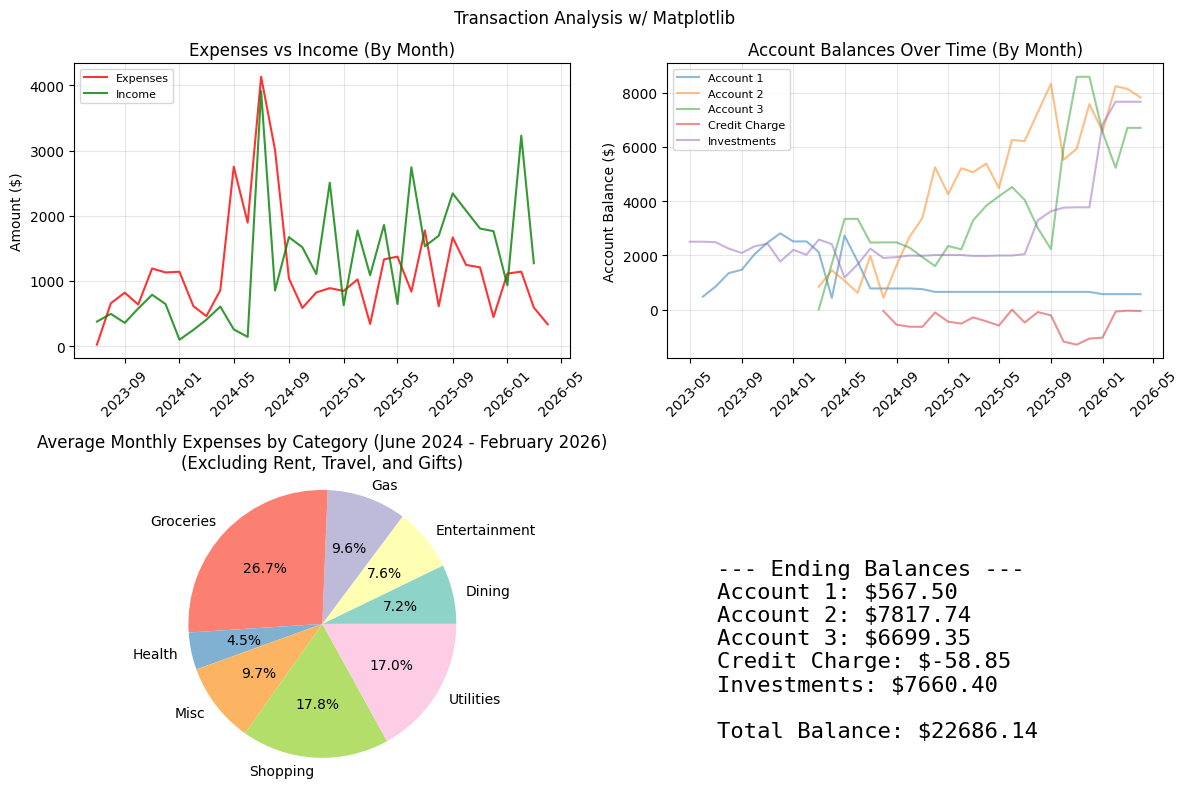

In [24]:
# Create the 2x2 plot
fig1, axes = plt.subplots(2, 2, figsize=(12, 8))
fig1.suptitle('Transaction Analysis w/ Matplotlib')

"""Expenses vs Income Subplot"""
# Plot expenses line
axes[0, 0].plot(expenses.index.to_timestamp(), expenses.values, label='Expenses', alpha =.8, color='red')
# Plot income line
axes[0,0].plot(income.index.to_timestamp(), income.values, label='Income', alpha= .8, color='green')
    
axes[0,0].set_title('Expenses vs Income (By Month)')
axes[0,0].set_ylabel('Amount ($)')
axes[0,0].legend(loc='upper left', fontsize=8)
axes[0,0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

"""Monthly Account Balances Subplot"""
# Plot each account
for account in monthly_balances.columns:
    axes[0,1].plot(monthly_balances.index.to_timestamp(), monthly_balances[account], label=account, alpha =.5,)
    
axes[0,1].set_title('Account Balances Over Time (By Month)')
axes[0,1].set_ylabel('Account Balance ($)')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)
axes[0,1].tick_params(axis='x', rotation=45)

"""Average Monthly Expense Pi Chart"""
colors_template = cm.Set3.colors 

axes[1,0].pie(avg_expenses.values, labels=avg_expenses.index, colors = colors_template, autopct='%1.1f%%')
axes[1,0].set_title('Average Monthly Expenses by Category (June 2024 - February 2026)\n(Excluding Rent, Travel, and Gifts)')
axes[1,0].axis('equal')

"""Ending Balances Summary"""
axes[1,1].axis("off")

ending_balances = df.groupby('Account')['Balance'].last()
summary_text = "\n--- Ending Balances ---\n"
for account, balance in ending_balances.items():
    if account != 'Credit Payment':
        summary_text += f"{account}: ${balance:.2f}\n"

total_balance = ending_balances.sum()
summary_text += f"\nTotal Balance: ${total_balance:.2f}"

axes[1,1].text(0.1, 0.8, summary_text, fontsize=16, verticalalignment='top', horizontalalignment='left', transform=axes[1,1].transAxes, family='monospace')

plt.tight_layout()
plt.show()

## Page 2

### Create Values for Page 2 of Report

Structuring data to use with visuals. Filtering out Credit Payments, grouping transactions by months.

In [25]:
# Create date range to include last 6 months
current_month = pd.Timestamp.now().to_period('M')
min_date = current_month - 6
max_date = transactions_df_with_future_balances['Date'].max().to_period('M')
date_range = pd.period_range(start=min_date, end=max_date, freq='M')

"""Projected Balance of All Accounts"""
# Group by month and account, then get the last balance for each account in each month
monthly_account_balances = transactions_df_with_future_balances.groupby([transactions_df_with_future_balances['Date'].dt.to_period('M'), 'Account'])['Balance'].last()

# Pivot to have accounts as columns and months as index
pivot_balances = monthly_account_balances.unstack(level='Account', fill_value=0)

# Reindex to include all months. Then fill in future blank balances with the most recent balance. Thank you jezrael on StackOverflow for you answer and qwww for you question
pivot_balances = pivot_balances.reindex(date_range)
pivot_balances = pivot_balances.replace(0,np.nan).ffill()

# Each months sum of all accounts
projected_balances = pivot_balances.sum(axis=1)

# Calculate average monthly spending across all categories
total_sums, average_sums = get_category_sums_and_averages(transactions_df_with_future_balances)
average_monthly_spending = average_sums.sum()

# Create projected balances by subtracting average monthly expenses for each month after present month
for i, (idx, value) in enumerate(projected_balances.items()):
    if idx > current_month:
        # Calculate how many months ahead
        months_ahead = (idx.year - current_month.year) * 12 + (idx.month - current_month.month)
        projected_balances.iloc[i] = value - (average_monthly_spending * months_ahead)

# Add the projected expenses as a new column to the original pivot table
pivot_balances['Projected Balances'] = projected_balances

"""Projected Investments Balance"""
# Filter for paycheck transactions
paycheck_transactions = transactions_df_with_future_balances[
    transactions_df_with_future_balances['Item'].str.contains('paycheck', case=False, na=False)]

# Group paycheck transactions by month
paycheck_by_month = paycheck_transactions.groupby(paycheck_transactions['Date'].dt.to_period('M'))['Amount'].sum()

# Create investment projections
investments_projection = pivot_balances['Investments'].copy()

# Track cumulative contributions
cumulative_contribution = 0

for idx, balance in investments_projection.items():
    if idx > current_month:
        # Calculate months ahead
        months_ahead = (idx.year - current_month.year) * 12 + (idx.month - current_month.month)
        
        # Get paycheck amount for this month (if exists) Do I need this???
        paycheck_amount = paycheck_by_month.get(idx, 0)
        
        # Calculate investment contribution only if paycheck covers expenses
        if paycheck_amount > average_monthly_spending:
            investment_contribution = (paycheck_amount - average_monthly_spending) * .10
        else:
            investment_contribution = 0
        
        # Add contribution to cumulative total
        cumulative_contribution += investment_contribution
        investments_projection[idx] = balance + cumulative_contribution
    elif idx == current_month:
        # For current month, start with existing balance
        investments_projection[idx] = balance + cumulative_contribution

# Add investment projection to pivot balances
pivot_balances['Projected Investments'] = investments_projection

### Create Page 2 of Report

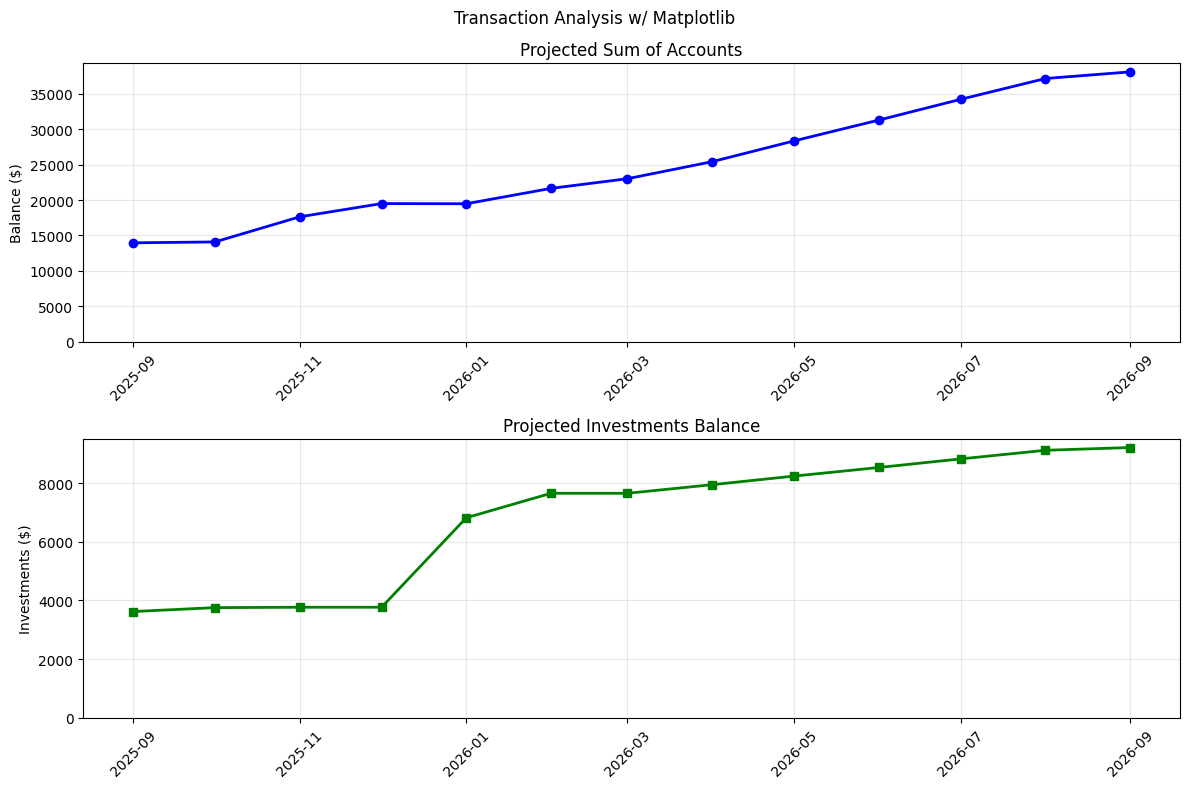

In [26]:
# Create 2x1 plot
fig2, axes = plt.subplots(2, 1, figsize=(12, 8))
fig2.suptitle('Transaction Analysis w/ Matplotlib')

"""Projected Balance of All Accounts"""
axes[0].plot(pivot_balances.index.to_timestamp(), pivot_balances['Projected Balances'].values, marker='o', linewidth=2, markersize=6, color='b')
axes[0].set_title('Projected Sum of Accounts')
axes[0].set_ylabel('Balance ($)')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(bottom=0) 

"""Projected Investments Balance"""
axes[1].plot(pivot_balances.index.to_timestamp(), pivot_balances['Projected Investments'].values, marker='s', linewidth=2, markersize=6, color='g')
axes[1].set_title('Projected Investments Balance')
axes[1].set_ylabel('Investments ($)')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## Export as PDF

In [27]:
from matplotlib.backends.backend_pdf import PdfPages

# Create PDF with both plots
with PdfPages('financial_analysis_report.pdf') as pdf:
    pdf.savefig(fig1)
    pdf.savefig(fig2)